# Experimentation with model

### Imports

In [1]:
import sys
sys.path.append("src")  
from src.llama_activate import (
    get_pipe,
    generate_new_net,
)

import src.utils.visualization as vis
import src.utils.metrics as metrics
import src.utils.reading_in as ri
import argparse
from utils.path_manager import PathManager

c:\Users\chris\Documents\courses\Thesis\Project\own_setup\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True


### Set variables

In [2]:
# Variables
rounds = 5
num_agents = 30
net = "sda"
seed = 53
alpha = 0.5
m = 2
degree = 3
p = 0.3
depressed = False
enforce_ngrams = False
use_existing_net = False
states = ["depressed", "enforce_ngrams", "basis"]
k = 0
pipe = get_pipe()
dim = 2
save = False

args = argparse.Namespace(
        net=net,
        rounds=rounds,
        num_agents=num_agents,
        seed=seed,
        m=m,
        p=p,
        k=k,
        depressed=depressed,
        enforce_ngrams=enforce_ngrams,
        alpha=alpha,
        degree = degree,
        dim = dim,
        save = save,
    )

`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0


### Generate network and run simulation

In [3]:

networks = []
running_fracs_nets = []
fracs_dist_step_nets = []
path_managers = {}
# retrieve existing networks with different states
if use_existing_net:
    for state in states:
        args.enforce_ngrams = (state == "enforce_ngrams")
        args.depressed = (state == "depressed")

        path_manager = PathManager(args=args)
        path_managers[state] = path_manager
        
        file_path = path_manager.get_full_network_path()
        
        # reload network from saved properties
        network, running_fracs, fracs_dist_step= ri.generate_network(file_path, pipe)
        networks.append(network)
        running_fracs_nets.append(running_fracs)
        fracs_dist_step_nets.append(fracs_dist_step)
else:
    networks, running_fracs, fracs_dist_step = generate_new_net(
        args,
        pipe,
    )
    network = networks[0][1]

<class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>
GENERATOR:  (inputs: Optional[torch.Tensor] = None, generation_config: Optional[transformers.generation.configuration_utils.GenerationConfig] = None, logits_processor: Optional[transformers.generation.logits_process.LogitsProcessorList] = None, stopping_criteria: Optional[transformers.generation.stopping_criteria.StoppingCriteriaList] = None, prefix_allowed_tokens_fn: Optional[Callable[[int, torch.Tensor], list[int]]] = None, synced_gpus: Optional[bool] = None, assistant_model: Optional[ForwardRef('PreTrainedModel')] = None, streamer: Optional[ForwardRef('BaseStreamer')] = None, negative_prompt_ids: Optional[torch.Tensor] = None, negative_prompt_attention_mask: Optional[torch.Tensor] = None, use_model_defaults: Optional[bool] = None, custom_generate: Union[str, Callable, NoneType] = None, **kwargs) -> Union[transformers.generation.utils.GenerateDecoderOnlyOutput, transformers.generation.utils.GenerateEncoderDecoderOutp

Values less than or equal to 0 in data. Throwing out 0 or negative values


Agent 8 FORCED TWEET OUTPUT: TWEET: I feel like I'm drowning in my own thoughts all the time. Just another day, another meaningless conversation on social media #mentalhealthmatters #depression
Agent 28 FORCED TWEET OUTPUT: TWEET: I'm starting a new year, but the same familiar feelings of anxiety creep in. Anyone else feeling stuck in the haze of daily routine? #MDD #anxiety
Agent 20 FORCED TWEET OUTPUT: TWEET: I'm feeling a bit more grounded today, thanks to some yoga practice and a warm bath #MentalHealthMatters
Agent 6 FORCED TWEET OUTPUT: I'm going through a tough week and feeling overwhelmed. Anyone else ever feel this way? #MentalHealthMatters
Agent 16 FORCED TWEET OUTPUT: TWEET: When you finally get to write a good post and get some likes but it's just one lonely post
Agent 25 FORCED TWEET OUTPUT: TWEET: Feeling lost in a sea of uncertainty every day TWEET:
Agent 5 FORCED TWEET OUTPUT: TWEET: 
I've had one night where I felt like I was floating on a cloud
Agent 15 FORCED TWEET O

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Round 3: Mean running fraction of distorted agents: 0.2333, Fraction distorted this step: 0.3333 
Round 4: Mean running fraction of distorted agents: 0.2500, Fraction distorted this step: 0.1429 
Round 5: Mean running fraction of distorted agents: 0.2556, Fraction distorted this step: 0.1538 


#### Visualize CDS

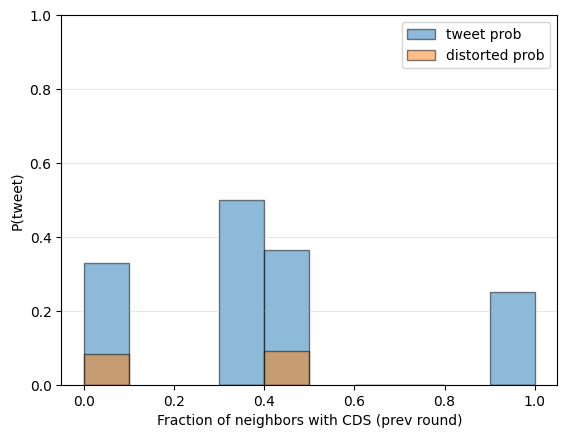

PHQ-9 assortativity: nan


c:\Users\chris\Documents\courses\Thesis\Project\own_setup\.venv\Lib\site-packages\networkx\algorithms\assortativity\mixing.py:113: RuntimeWarning: invalid value encountered in divide
  a = a / a.sum()


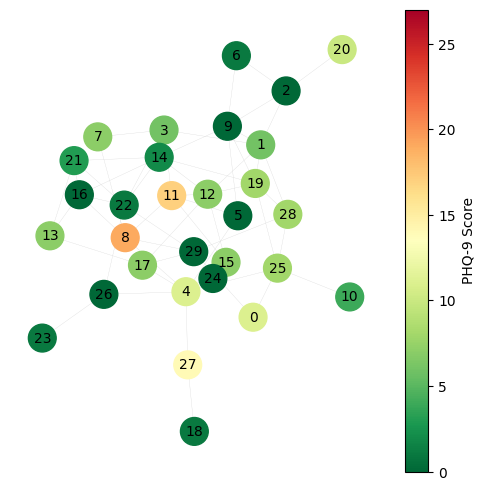

In [4]:
vis.distorted_info(network.cds_info)
graph = vis.print_network_phq9(network)

#### Generate PCA plots

In [5]:
# plot TF-IDF PCA
n_grams = metrics.load_ngrams_tsv("data/distorted_language_ngrams.tsv")
global_tf_idf, _, _ = metrics.retrieve_tf_idf(networks, num_steps=100, shift=5, n_grams=n_grams)
pca_runs = metrics.reduce_dimensionality(global_tf_idf, n_components=2)
vis.plot_tf_idf_PCA(pca_runs, states, num_steps=100, shift=5)

AttributeError: 'tuple' object has no attribute 'iterations'

#### Generate plots concerning distorted info

In [ ]:
for i, network in enumerate(networks):

    print(f"Plotting results for network with state: {states[i]}")
    vis.plot_running_fracs(
        running_fracs_nets[i],
        network.m if hasattr(network, "m") else 0,
        network.p if hasattr(network, "p") else 0.0,
        enforced_ngrams=(states[i] == "enforce_ngrams"),
        depressed=(states[i] == "depressed"),
        type_nn=net,
    )
    
    vis.plot_distorted_fracs(
        fracs_dist_step_nets[i],
        network.m if hasattr(network, "m") else 0,
        network.p if hasattr(network, "p") else 0.0,
        enforced_ngrams=(states[i] == "enforce_ngrams"),
        depressed=(states[i] == "depressed"),
        type_nn=net,
    )


### activation plot

In [ ]:
vis.distorted_info(network.cds_info)
vis.print_network_phq9(network)
